### Weights & Biases Setup
This section installs the `wandb` library and logs into your Weights & Biases account. It attempts a non-interactive login using the `WANDB_API_KEY` stored in Colab secrets. If the key is not found, it will attempt an interactive login.

In [1]:
# Install wandb library
!pip install wandb -qqq

# import colab user data
from google.colab import userdata
import wandb

# Log in to wandb non-interactively using the API key from Colab secrets
wandb_api_key = userdata.get('WANDB_API_KEY')
if wandb_api_key:
  print("WANDB_API_KEY found. Attempting non-interactive login to Weights & Biases.")
  wandb.login(key=wandb_api_key)
else:
  print("WANDB_API_KEY not found in environment variables. Attempting interactive login.")
  print("Please ensure your W&B API key is set as a secret named 'WANDB_API_KEY' in Colab or your environment.")
  wandb.login()

WANDB_API_KEY found. Attempting non-interactive login to Weights & Biases.


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gbera23 (gbera23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### GitHub Repository Cloning
This section clones the specified GitHub repository. It attempts to use a GitHub Personal Access Token (`GITHUB_TOKEN`) stored in Colab secrets for private repositories. If no token is found, it will attempt to clone the repository directly, which will only succeed for public repositories or if credentials are otherwise configured.

In [2]:
import os

# GitHub repository cloning
# If the repository is private, a Personal Access Token (PAT) is required.
# Assuming 'github' (which is the GITHUB_TOKEN) is available as a secret.
github_token = userdata.get('github')
repo_url = "https://github.com/gbera23-dev/Machine-Learning.git"

if github_token:
  print("GITHUB_TOKEN found. Attempting to clone GitHub repository using token.")
  # Embed the token in the URL for cloning private repos
  !git clone https://{github_token}@github.com/gbera23-dev/Machine-Learning.git
else:
  print("GITHUB_TOKEN not found in environment variables. Attempting to clone repository without explicit token.")
  print("If the repository is private, please ensure your GitHub Personal Access Token is set as a secret named 'github' in Colab or your environment.")
  !git clone {repo_url}

# Verify the repository was cloned
if os.path.exists("Machine-Learning"):
    print("Repository 'Machine-Learning' cloned successfully.")
else:
    print("Failed to clone repository 'Machine-Learning'. Please check your GitHub token if it's a private repo.")

GITHUB_TOKEN found. Attempting to clone GitHub repository using token.
fatal: destination path 'Machine-Learning' already exists and is not an empty directory.
Repository 'Machine-Learning' cloned successfully.


In [ ]:
# Install the Kaggle API client
!pip install kaggle -qqq

### Kaggle authorization

In [3]:
%cd Machine-Learning/Assignment4

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


%ls

/content/Machine-Learning/Assignment4
mv: cannot stat 'kaggle.json': No such file or directory
challenges-in-representation-learning-facial-expression-recognition-challenge_data/
challenges-in-representation-learning-facial-expression-recognition-challenge.zip
deep_pipeline_lr0.0001_bs128.pth
deep_pipeline_lr0.0001_bs32.pth
deep_pipeline_lr0.0005_bs128.pth
deep_pipeline_lr0.0005_bs32.pth
deep_pipeline_lr0.001_bs128.pth
deep_pipeline_lr0.001_bs32.pth
model_files/
pipeline_v_lr0.0001_bs128.pth
pipeline_v_lr0.0001_bs32.pth
pipeline_v_lr0.0005_bs128.pth
pipeline_v_lr0.0005_bs32.pth
pipeline_v_lr0.001_bs128.pth
pipeline_v_lr0.001_bs32.pth
pipeline_v_lr0.005_bs128.pth
pipeline_v_lr0.005_bs32.pth
pipeline_v_lr0.01_bs128.pth
pipeline_v_lr0.01_bs32.pth
README.md
resnet_pipeline_lr0.0005_bs32.pth
resnet_pipeline_lr0.001_bs32.pth
resnet_val_lr0.0005_bs32.pth
wandb/


### Download Kaggle Competition Data

Now, we can download the data for the 'Challenges in Representation Learning, Facial Expression Recognition Challenge' competition. The competition name on Kaggle is `challenges-in-representation-learning-facial-expression-recognition-challenge`.

In [ ]:
# Define the competition name
competition_name = 'challenges-in-representation-learning-facial-expression-recognition-challenge'

# Download the competition data
!kaggle competitions download -c {competition_name}

### Unzip the Downloaded Data

In [ ]:
zip_file_name = f"{competition_name}.zip"

!unzip -q {zip_file_name} -d "./{competition_name}_data"

!ls -F "./{competition_name}_data"

print(f"Data unzipped to ./{competition_name}_data")

### Change directory to Machine-Learning

In [ ]:
# %cd Machine-Learning

## 1. Exploratory Data Analysis (EDA)
We will load the dataset and visualize the classes to understand the distribution of emotions.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path to the data
data_path = './challenges-in-representation-learning-facial-expression-recognition-challenge_data/icml_face_data.csv'
df = pd.read_csv(data_path)

# Display basic info
print(f"Dataset Shape: {df.shape}")
display(df.head())

# Check the usage split (Training, PublicTest, PrivateTest)
print("\nUsage distribution:")
print(df[' Usage'].value_counts())

Dataset Shape: (35887, 3)


,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...



Usage distribution:
 Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


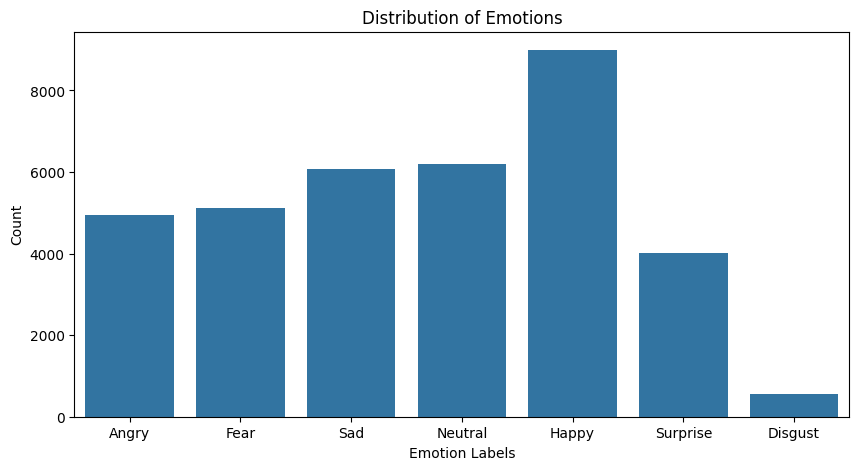

In [5]:
# Emotion mapping
emotion_map = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# Visualize Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=df['emotion'].map(emotion_map))
plt.title('Distribution of Emotions')
plt.xlabel('Emotion Labels')
plt.ylabel('Count')
plt.show()

Sample images from the dataset:


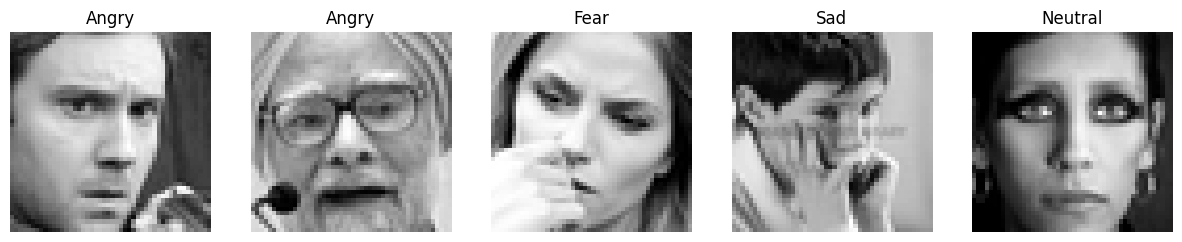

In [6]:
def plot_samples(df, num_samples=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):

        pixels = df.iloc[i][' pixels'].split()
        image = np.array(pixels, dtype='float32').reshape(48, 48)

        plt.subplot(1, num_samples, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(emotion_map[df.iloc[i]['emotion']])
        plt.axis('off')
    plt.show()

print("Sample images from the dataset:")
plot_samples(df)

### 1.2 Deep Dive into Data Structure
Let's look at the raw training data structure and the distribution of pixel intensities across all images.

Raw Pixel Data Example (First 50 characters of the first row):
70 80 82 72 58 58 60 63 54 58 60 48 89 115 121 119...


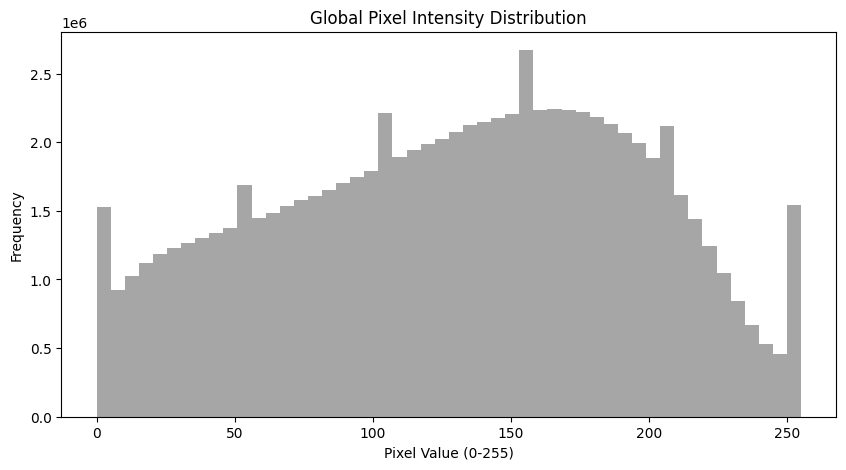

In [7]:
print("Raw Pixel Data Example (First 50 characters of the first row):")
print(df.loc[0, ' pixels'][:50] + "...")

all_pixels = np.array([np.fromstring(x, dtype=int, sep=' ') for x in df[' pixels']])

plt.figure(figsize=(10, 5))
plt.hist(all_pixels.flatten(), bins=50, color='gray', alpha=0.7)

plt.title('Global Pixel Intensity Distribution')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Frequency')
plt.show()

## 2. Data Preparation
We will create a custom PyTorch Dataset to handle the conversion of pixel strings to tensors and apply basic normalization.

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Extract pixels and label
        pixels = self.df.iloc[idx][' pixels'].split()
        image = np.array(pixels, dtype='float32').reshape(48, 48)
        label = int(self.df.iloc[idx]['emotion'])

        # Add channel dimension (H, W) -> (H, W, C) for transforms
        image = image[:, :, np.newaxis] / 255.0

        if self.transform:
            image = self.transform(image)

        return image, label

# Define basic transforms
train_transform = transforms.Compose([
    transforms.ToTensor(),
    # Note: We can add augmentation here later
    transforms.Normalize((0.5,), (0.5,))
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Split the dataframe based on ' Usage'
train_df = df[df[' Usage'] == 'Training']
val_df = df[df[' Usage'] == 'PublicTest']

# Initialize Datasets
train_dataset = FERDataset(train_df, transform=train_transform)
val_dataset = FERDataset(val_df, transform=val_transform)

# Create Dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"DataLoaders created with {len(train_dataset)} training and {len(val_dataset)} validation samples.")

DataLoaders created with 28709 training and 3589 validation samples.


In [9]:
import pandas as pd

# Verification of Data Split integrity
train_indices = set(train_df.index)
val_indices = set(val_df.index)

overlap = train_indices.intersection(val_indices)

print(f"Total Training samples: {len(train_df)}")
print(f"Total Validation samples: {len(val_df)}")
print(f"Number of overlapping samples: {len(overlap)}")

if len(overlap) == 0:
    print("SUCCESS: No data leakage. The sets are strictly independent.")
else:
    print("WARNING: Data leakage detected!")

Total Training samples: 28709
Total Validation samples: 3589
Number of overlapping samples: 0
SUCCESS: No data leakage. The sets are strictly independent.


## 3. Model Development
### 3.3 Iteration 3: Residual Network (ResNet)
In this version, we implement a Residual Network. Residual connections (skip connections) help in training much deeper networks by allowing the gradient to bypass layers, preventing degradation and vanishing gradients.

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

class ResNetFER(nn.Module):
    def __init__(self, block, num_blocks, num_classes=7):
        super(ResNetFER, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

def ResNet18FER(num_classes=7):
    return ResNetFER(ResidualBlock, [2, 2, 2], num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet18FER(num_classes=7).to(device)
print(f"ResNet-18 initialized on device: {device}")

ResNet-18 initialized on device: cuda


### 3.2 Define Loss Function and Optimizer
We will use CrossEntropyLoss (standard for classification) and the Adam optimizer.

In [11]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer defined.")

Loss function and optimizer defined.


### 3.4 Training Loop
We iterate through the training data, update the model weights, and log metrics to W&B.

Create sweep with ID: 6iw06ud8
Sweep URL: https://wandb.ai/gbera23-free-university-of-tbilisi-/facial-expression-recognition/sweeps/6iw06ud8


wandb: Agent Starting Run: nlsitn8s with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: decent-sweep-1 | Epoch 1: T-Loss: 1.6381, V-Loss: 1.9749, T-Acc: 34.51%, V-Acc: 28.31%
Run: decent-sweep-1 | Epoch 2: T-Loss: 1.3156, V-Loss: 1.3241, T-Acc: 49.70%, V-Acc: 48.62%
Run: decent-sweep-1 | Epoch 3: T-Loss: 1.1888, V-Loss: 1.3162, T-Acc: 54.96%, V-Acc: 50.99%
Run: decent-sweep-1 | Epoch 4: T-Loss: 1.1021, V-Loss: 1.2370, T-Acc: 58.32%, V-Acc: 54.36%
Run: decent-sweep-1 | Epoch 5: T-Loss: 1.0402, V-Loss: 1.1383, T-Acc: 60.63%, V-Acc: 57.51%


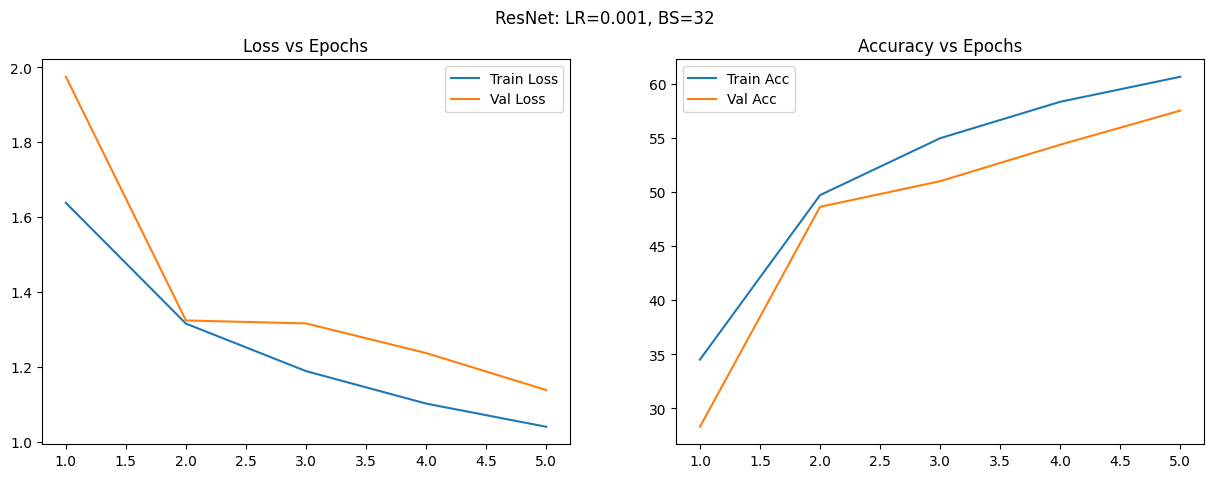

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


epoch,▁▃▅▆█
train_accuracy,▁▅▆▇█
train_loss,█▄▃▂▁
val_accuracy,▁▆▆▇█
val_loss,█▃▂▂▁
epoch,5
train_accuracy,60.63255
train_loss,1.04015
val_accuracy,57.50906
val_loss,1.1383


wandb: Agent Starting Run: lk6i8f1x with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.0005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: young-sweep-2 | Epoch 1: T-Loss: 1.6542, V-Loss: 1.4480, T-Acc: 33.50%, V-Acc: 42.77%
Run: young-sweep-2 | Epoch 2: T-Loss: 1.3023, V-Loss: 1.3935, T-Acc: 50.34%, V-Acc: 47.76%
Run: young-sweep-2 | Epoch 3: T-Loss: 1.1680, V-Loss: 1.3211, T-Acc: 55.64%, V-Acc: 50.85%
Run: young-sweep-2 | Epoch 4: T-Loss: 1.0780, V-Loss: 1.1651, T-Acc: 59.33%, V-Acc: 56.20%
Run: young-sweep-2 | Epoch 5: T-Loss: 1.0068, V-Loss: 1.4451, T-Acc: 62.18%, V-Acc: 47.39%


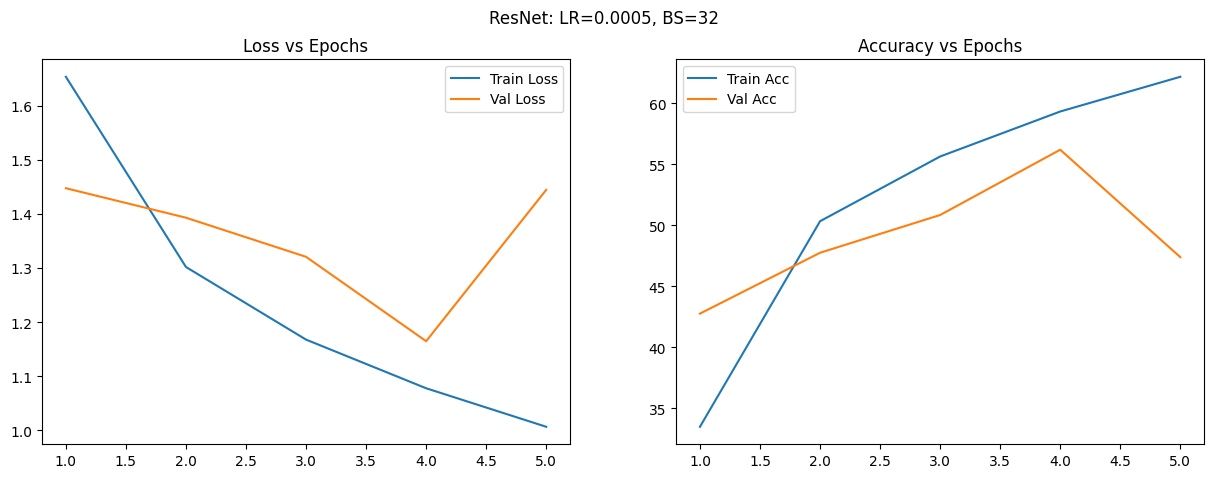

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


epoch,▁▃▅▆█
train_accuracy,▁▅▆▇█
train_loss,█▄▃▂▁
val_accuracy,▁▄▅█▃
val_loss,█▇▅▁█
epoch,5
train_accuracy,62.17562
train_loss,1.0068
val_accuracy,47.39482
val_loss,1.44509


wandb: Agent Starting Run: aw1o0u06 with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.0001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: pious-sweep-3 | Epoch 1: T-Loss: 1.5287, V-Loss: 1.4280, T-Acc: 39.94%, V-Acc: 45.33%
Run: pious-sweep-3 | Epoch 2: T-Loss: 1.2149, V-Loss: 1.1834, T-Acc: 54.09%, V-Acc: 54.47%
Run: pious-sweep-3 | Epoch 3: T-Loss: 1.0854, V-Loss: 1.3498, T-Acc: 59.22%, V-Acc: 52.58%
Run: pious-sweep-3 | Epoch 4: T-Loss: 0.9833, V-Loss: 1.3715, T-Acc: 63.72%, V-Acc: 50.79%
Run: pious-sweep-3 | Epoch 5: T-Loss: 0.8677, V-Loss: 1.1601, T-Acc: 68.10%, V-Acc: 57.90%


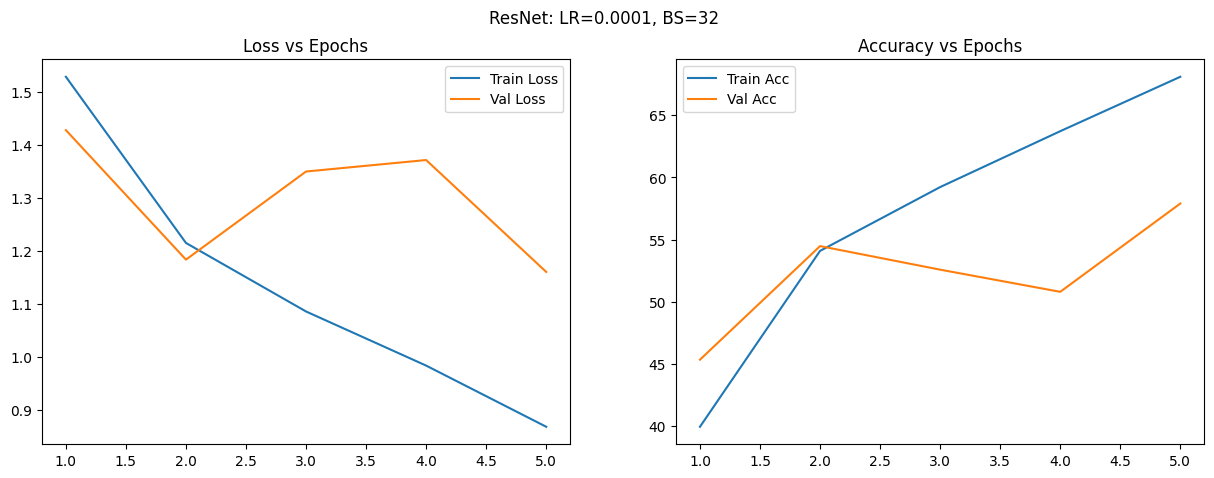

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


epoch,▁▃▅▆█
train_accuracy,▁▅▆▇█
train_loss,█▅▃▂▁
val_accuracy,▁▆▅▄█
val_loss,█▂▆▇▁
epoch,5
train_accuracy,68.09711
train_loss,0.86771
val_accuracy,57.89914
val_loss,1.16014


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: fei0iyv1 with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: wild-sweep-4 | Epoch 1: T-Loss: 1.7350, V-Loss: 1.9080, T-Acc: 29.35%, V-Acc: 29.65%
Run: wild-sweep-4 | Epoch 2: T-Loss: 1.4023, V-Loss: 2.3462, T-Acc: 46.09%, V-Acc: 25.30%
Run: wild-sweep-4 | Epoch 3: T-Loss: 1.2118, V-Loss: 1.7940, T-Acc: 53.93%, V-Acc: 37.81%
Run: wild-sweep-4 | Epoch 4: T-Loss: 1.1148, V-Loss: 1.2374, T-Acc: 57.72%, V-Acc: 51.27%
Run: wild-sweep-4 | Epoch 5: T-Loss: 1.0285, V-Loss: 1.1892, T-Acc: 61.41%, V-Acc: 56.76%


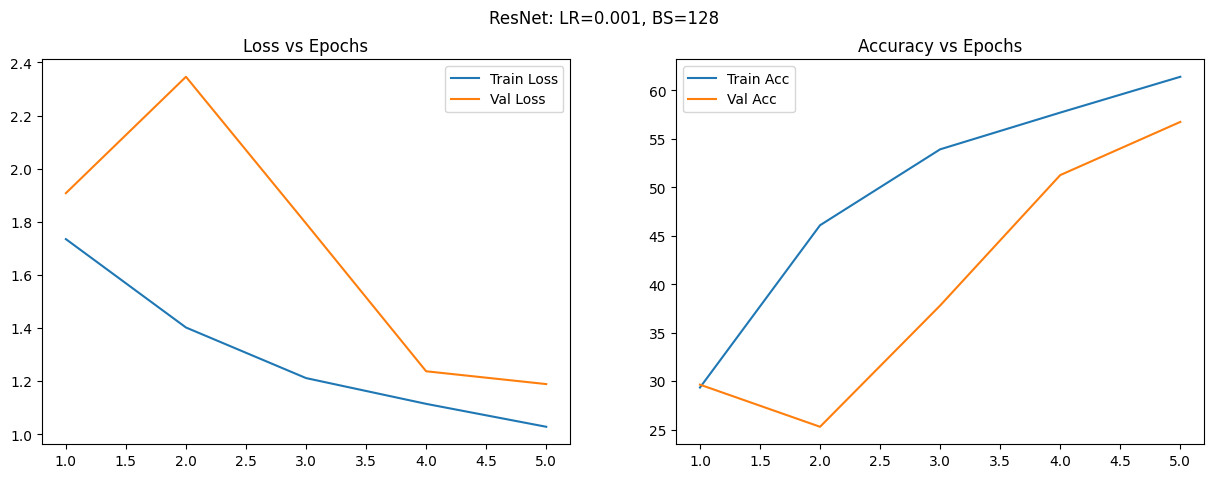

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


epoch,▁▃▅▆█
train_accuracy,▁▅▆▇█
train_loss,█▅▃▂▁
val_accuracy,▂▁▄▇█
val_loss,▅█▅▁▁
epoch,5
train_accuracy,61.4128
train_loss,1.02849
val_accuracy,56.75676
val_loss,1.18924


wandb: Agent Starting Run: weyvks84 with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.0005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: unique-sweep-5 | Epoch 1: T-Loss: 1.5524, V-Loss: 1.5154, T-Acc: 38.83%, V-Acc: 43.19%
Run: unique-sweep-5 | Epoch 2: T-Loss: 1.2289, V-Loss: 1.4497, T-Acc: 53.46%, V-Acc: 46.50%
Run: unique-sweep-5 | Epoch 3: T-Loss: 1.1144, V-Loss: 1.5180, T-Acc: 58.14%, V-Acc: 47.06%
Run: unique-sweep-5 | Epoch 4: T-Loss: 1.0289, V-Loss: 1.1458, T-Acc: 61.15%, V-Acc: 57.26%
Run: unique-sweep-5 | Epoch 5: T-Loss: 0.9509, V-Loss: 1.2162, T-Acc: 64.60%, V-Acc: 56.23%


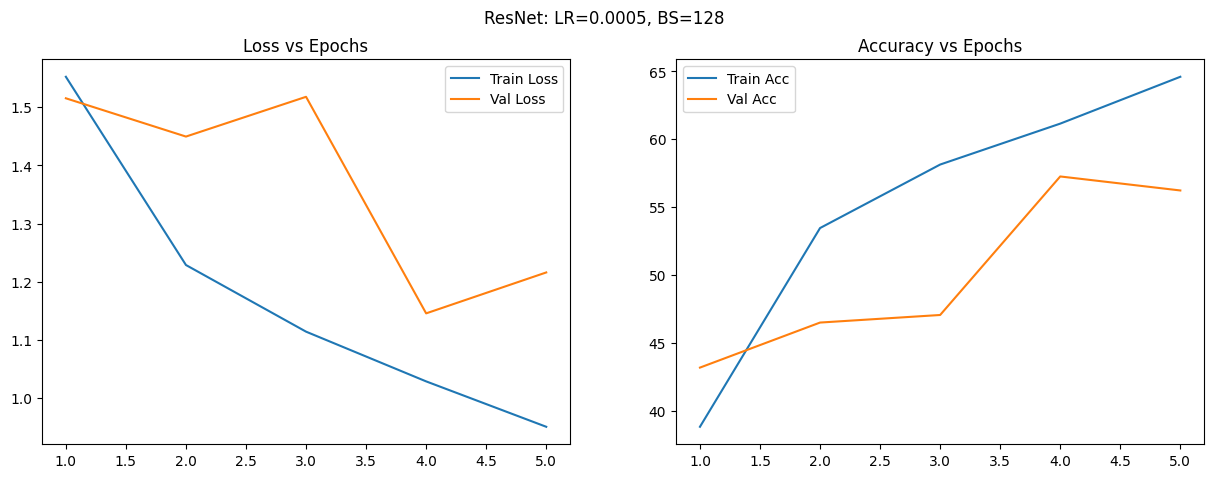

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


epoch,▁▃▅▆█
train_accuracy,▁▅▆▇█
train_loss,█▄▃▂▁
val_accuracy,▁▃▃█▇
val_loss,█▇█▁▂
epoch,5
train_accuracy,64.59647
train_loss,0.95093
val_accuracy,56.22736
val_loss,1.21615


wandb: Agent Starting Run: nst9o5pw with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.0001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: earthy-sweep-6 | Epoch 1: T-Loss: 1.6217, V-Loss: 1.4759, T-Acc: 35.85%, V-Acc: 41.88%
Run: earthy-sweep-6 | Epoch 2: T-Loss: 1.2909, V-Loss: 1.3414, T-Acc: 51.17%, V-Acc: 50.52%
Run: earthy-sweep-6 | Epoch 3: T-Loss: 1.1375, V-Loss: 1.3899, T-Acc: 57.42%, V-Acc: 46.84%
Run: earthy-sweep-6 | Epoch 4: T-Loss: 1.0120, V-Loss: 1.3281, T-Acc: 62.63%, V-Acc: 50.99%
Run: earthy-sweep-6 | Epoch 5: T-Loss: 0.8759, V-Loss: 1.3103, T-Acc: 68.37%, V-Acc: 53.86%


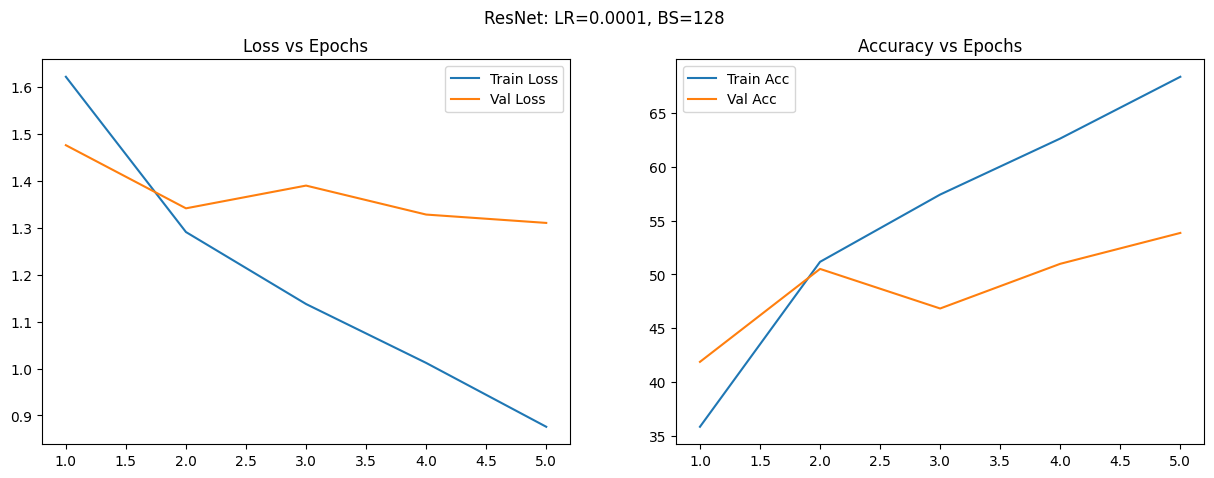

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


epoch,▁▃▅▆█
train_accuracy,▁▄▆▇█
train_loss,█▅▃▂▁
val_accuracy,▁▆▄▆█
val_loss,█▂▄▂▁
epoch,5
train_accuracy,68.3688
train_loss,0.87587
val_accuracy,53.85901
val_loss,1.31031


In [12]:
import matplotlib.pyplot as plt
import wandb
import torch
import torch.nn as nn

class FERPipeline(nn.Module):
    def __init__(self, model, transform):
        super(FERPipeline, self).__init__()
        self.model = model
        self.transform = transform

    def forward(self, x):
        return self.model(x)

def train_sweep():
    with wandb.init() as run:
        config = run.config
        # Initialize ResNet-18
        sweep_model = ResNet18FER(num_classes=7).to(device)
        sweep_optimizer = optim.Adam(sweep_model.parameters(), lr=config.learning_rate)
        sweep_train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
        sweep_val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)
        current_pipeline = FERPipeline(sweep_model, val_transform)

        train_loss_history = []
        train_acc_history = []
        val_loss_history = []
        val_acc_history = []
        num_epochs = 5

        for epoch in range(num_epochs):
            # --- Training Phase ---
            sweep_model.train()
            running_loss = 0.0
            train_correct = 0
            train_total = 0
            for images, labels in sweep_train_loader:
                images, labels = images.to(device), labels.to(device)
                sweep_optimizer.zero_grad()
                outputs = sweep_model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                sweep_optimizer.step()
                running_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                train_total += labels.size(0)
                train_correct += (predicted == labels).sum().item()

            avg_train_loss = running_loss / len(sweep_train_loader)
            train_accuracy = 100 * train_correct / train_total

            # --- Validation Phase ---
            sweep_model.eval()
            val_correct = 0
            val_total = 0
            running_val_loss = 0.0
            with torch.no_grad():
                for images, labels in sweep_val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = sweep_model(images)
                    loss = criterion(outputs, labels)
                    running_val_loss += loss.item()
                    _, predicted = torch.max(outputs.data, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()

            avg_val_loss = running_val_loss / len(sweep_val_loader)
            val_accuracy = 100 * val_correct / val_total

            train_loss_history.append(avg_train_loss)
            train_acc_history.append(train_accuracy)
            val_loss_history.append(avg_val_loss)
            val_acc_history.append(val_accuracy)

            # Log metrics to W&B
            wandb.log({
                "epoch": epoch + 1,
                "train_loss": avg_train_loss,
                "train_accuracy": train_accuracy,
                "val_loss": avg_val_loss,
                "val_accuracy": val_accuracy
            })

            print(f"Run: {run.name} | Epoch {epoch+1}: T-Loss: {avg_train_loss:.4f}, V-Loss: {avg_val_loss:.4f}, T-Acc: {train_accuracy:.2f}%, V-Acc: {val_accuracy:.2f}%")

        # Local Visualization for Loss and Accuracy
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        ax1.plot(range(1, num_epochs + 1), train_loss_history, label='Train Loss')
        ax1.plot(range(1, num_epochs + 1), val_loss_history, label='Val Loss')
        ax1.set_title("Loss vs Epochs")
        ax1.legend()

        ax2.plot(range(1, num_epochs + 1), train_acc_history, label='Train Acc')
        ax2.plot(range(1, num_epochs + 1), val_acc_history, label='Val Acc')
        ax2.set_title("Accuracy vs Epochs")
        ax2.legend()

        plt.suptitle(f"ResNet: LR={config.learning_rate}, BS={config.batch_size}")
        plt.show()

        # Log Pipeline artifact
        model_filename = f"resnet_pipeline_lr{config.learning_rate}_bs{config.batch_size}.pth"
        torch.save(current_pipeline.state_dict(), model_filename)
        wandb.save(model_filename)

# Sweep configuration
sweep_config = {
    'method': 'grid',
    'parameters': {
        'learning_rate': {"values": [0.001, 0.0005, 0.0001]},
        'batch_size': {"values": [32, 128]}
    }
}

sweep_id = wandb.sweep(sweep_config, project="facial-expression-recognition")
wandb.agent(sweep_id, function=train_sweep, count=6)